**Yilin Pan, Daniel Lyu**

Spring 2026

CS 443: Bio-inspired Machine Learning

Project 2: Predictive Coding

#### Week 3: Building a convolutional predictive coding network

Despite its neat generative capabilities, the dense PCN falls far short in terms of image classification accuracy compared to our Hebbian encoder-decoder system. The focus this week is to integrate elements from the PCN into a backpropagation-based CNN (**convolutional PCN**) and explore how the addition of these bio-inspired components can result in much, much improved classification accuracy for CIFAR-10 🚀.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.show()
plt.rcParams.update({'font.size': 18})

np.set_printoptions(suppress=True, precision=3)

%load_ext autoreload
%autoreload 2

## Task 5: Implement CNN layers

In `conv_layers.py`, implement the following classes for familiar layers that we will need to build our convolutional PCN:
1. `Conv2D`: 2D convolutional layer.
2. `MaxPool2D`: 2D max pooling layer.

Additionally, implement the following new type of layer:

3. `Conv2DTranspose`: Transposed 2D convolutional layer. This will serve as the feedback connections in the PCN to transmit the prediction to the layer below.

### 5a. Implement and test `Conv2D` layer class

These methods are in the `Conv2D` class in `conv_layers.py`:
- Constructor
- `has_wts`
- `init_params(input_shape)`
- `compute_net_input(x)`.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
project_path = '/content/drive/MyDrive/ColabNotebooks/project2'
os.chdir(project_path)

In [4]:
from conv_layers import Conv2D

#### Test: Conv2D layer basics

In [5]:
tf.random.set_seed(2)
x_test_input2 = tf.random.uniform(shape=(1, 2, 2, 1), minval=-2, maxval=2)
conv = Conv2D('convoluted', 5, kernel_size=(2, 2), activation='relu', prev_layer_or_block=None, wt_scale=1e-2)
print(f'Conv2D layer is called {conv.get_name()} and has previous layer {conv.get_prev_layer_or_block()}')
print('You should see:')
print('Conv2D layer is called convoluted and has previous layer None')
print(f'Does the layer have weights? {conv.has_wts()}. It should be True.')

print('----------Initializing wts and biases Test1/2----------')
conv.init_params(input_shape=x_test_input2.shape)
print(f'Your wts:\n{conv.get_wts().numpy()} They should be:')
print('''[[[[-0.     0.01  -0.011  0.003  0.008]]

  [[ 0.008  0.028  0.012 -0.005 -0.014]]]


 [[[ 0.005 -0.001  0.011  0.011  0.005]]

  [[-0.003  0.001  0.007 -0.002  0.018]]]]''')
print(f'Your biases:\n{conv.get_b().numpy()} They should be:')
print('''[0. 0. 0. 0. 0.]''')


Conv2D layer is called convoluted and has previous layer None
You should see:
Conv2D layer is called convoluted and has previous layer None
Does the layer have weights? True. It should be True.
----------Initializing wts and biases Test1/2----------
Your wts:
[[[[-0.     0.01  -0.011  0.003  0.008]]

  [[ 0.008  0.028  0.012 -0.005 -0.014]]]


 [[[ 0.005 -0.001  0.011  0.011  0.005]]

  [[-0.003  0.001  0.007 -0.002  0.018]]]] They should be:
[[[[-0.     0.01  -0.011  0.003  0.008]]

  [[ 0.008  0.028  0.012 -0.005 -0.014]]]


 [[[ 0.005 -0.001  0.011  0.011  0.005]]

  [[-0.003  0.001  0.007 -0.002  0.018]]]]
Your biases:
[0. 0. 0. 0. 0.] They should be:
[0. 0. 0. 0. 0.]


In [6]:
tf.random.set_seed(1)
print('----------Initializing wts and biases Test2/2----------')
conv.init_params(input_shape=(2, 5, 5, 2))
print(f'Your wts:\n{conv.get_wts().numpy()} They should be:')
print('''[[[[-0.011  0.015  0.004 -0.009 -0.012]
   [-0.01   0.001 -0.002 -0.006 -0.007]]

  [[-0.006 -0.007 -0.003 -0.003  0.002]
   [ 0.011  0.013 -0.    -0.003  0.004]]]


 [[[ 0.003  0.006  0.021 -0.008 -0.009]
   [ 0.014  0.012  0.001 -0.005 -0.008]]

  [[-0.002 -0.004 -0.007 -0.01   0.004]
   [-0.01  -0.016 -0.002 -0.004 -0.002]]]]''')
print(f'Your biases:\n{conv.get_b().numpy()} They should be:')
print('''[0. 0. 0. 0. 0.]''')

----------Initializing wts and biases Test2/2----------
Your wts:
[[[[-0.011  0.015  0.004 -0.009 -0.012]
   [-0.01   0.001 -0.002 -0.006 -0.007]]

  [[-0.006 -0.007 -0.003 -0.003  0.002]
   [ 0.011  0.013 -0.    -0.003  0.004]]]


 [[[ 0.003  0.006  0.021 -0.008 -0.009]
   [ 0.014  0.012  0.001 -0.005 -0.008]]

  [[-0.002 -0.004 -0.007 -0.01   0.004]
   [-0.01  -0.016 -0.002 -0.004 -0.002]]]] They should be:
[[[[-0.011  0.015  0.004 -0.009 -0.012]
   [-0.01   0.001 -0.002 -0.006 -0.007]]

  [[-0.006 -0.007 -0.003 -0.003  0.002]
   [ 0.011  0.013 -0.    -0.003  0.004]]]


 [[[ 0.003  0.006  0.021 -0.008 -0.009]
   [ 0.014  0.012  0.001 -0.005 -0.008]]

  [[-0.002 -0.004 -0.007 -0.01   0.004]
   [-0.01  -0.016 -0.002 -0.004 -0.002]]]]
Your biases:
[0. 0. 0. 0. 0.] They should be:
[0. 0. 0. 0. 0.]


#### Test: Conv2D layer forward pass 1/2

This tests your `Conv2D` layer methods via your`__call__` implementation in `Layer`.

In [7]:
tf.random.set_seed(1)
conv = Conv2D('convoluted', 3, kernel_size=(3, 3), activation='relu', prev_layer_or_block=None)
x_test_input2 = tf.random.uniform(shape=(1, 3, 3, 4), minval=-2, maxval=2)
print('Your activations from Conv2D w/ ReLU:')
test_acts = conv(x_test_input2)
print(test_acts.numpy())
print('they should be:')
print('''[[[[0.003 0.005 0.006]
   [0.    0.    0.007]
   [0.009 0.005 0.   ]]

  [[0.    0.    0.   ]
   [0.    0.001 0.   ]
   [0.005 0.    0.   ]]

  [[0.    0.    0.   ]
   [0.    0.001 0.007]
   [0.    0.    0.   ]]]]''')

Your activations from Conv2D w/ ReLU:
[[[[0.003 0.005 0.006]
   [0.    0.    0.007]
   [0.009 0.005 0.   ]]

  [[0.    0.    0.   ]
   [0.    0.001 0.   ]
   [0.005 0.    0.   ]]

  [[0.    0.    0.   ]
   [0.    0.001 0.007]
   [0.    0.    0.   ]]]]
they should be:
[[[[0.003 0.005 0.006]
   [0.    0.    0.007]
   [0.009 0.005 0.   ]]

  [[0.    0.    0.   ]
   [0.    0.001 0.   ]
   [0.005 0.    0.   ]]

  [[0.    0.    0.   ]
   [0.    0.001 0.007]
   [0.    0.    0.   ]]]]


#### Test: Conv2D layer forward pass 2/2

This tests lazy initialization.

In [8]:
tf.random.set_seed(1)
conv = Conv2D('convoluted', 3, kernel_size=(3, 3), activation='linear', prev_layer_or_block=None)
x_test_input2 = tf.random.uniform(shape=(1, 3, 3, 4), minval=-2, maxval=2)
print('Your activations from Dense_2 w/ linear:')
for i in range(5):
    test_acts = conv(x_test_input2)
print(test_acts.numpy())
print('they should be:')
print('''[[[[ 0.003  0.005  0.006]
   [-0.006  0.     0.007]
   [ 0.009  0.005 -0.   ]]

  [[-0.002 -0.005 -0.011]
   [-0.     0.001 -0.002]
   [ 0.005 -0.006 -0.005]]

  [[-0.005 -0.002 -0.006]
   [-0.003  0.001  0.007]
   [-0.006 -0.002 -0.007]]]]''')

Your activations from Dense_2 w/ linear:
[[[[ 0.003  0.005  0.006]
   [-0.006  0.     0.007]
   [ 0.009  0.005 -0.   ]]

  [[-0.002 -0.005 -0.011]
   [-0.     0.001 -0.002]
   [ 0.005 -0.006 -0.005]]

  [[-0.005 -0.002 -0.006]
   [-0.003  0.001  0.007]
   [-0.006 -0.002 -0.007]]]]
they should be:
[[[[ 0.003  0.005  0.006]
   [-0.006  0.     0.007]
   [ 0.009  0.005 -0.   ]]

  [[-0.002 -0.005 -0.011]
   [-0.     0.001 -0.002]
   [ 0.005 -0.006 -0.005]]

  [[-0.005 -0.002 -0.006]
   [-0.003  0.001  0.007]
   [-0.006 -0.002 -0.007]]]]


#### Test: `__str__` and output shape

In [9]:
print(conv)
print('The above should print:')
print('Conv2D layer output(convoluted) shape: [1, 3, 3, 3]')

Conv2D layer output(convoluted) shape: [1, 3, 3, 3]
The above should print:
Conv2D layer output(convoluted) shape: [1, 3, 3, 3]


### 5b. Implement and test `MaxPool2D` layer

In [10]:
from conv_layers import MaxPool2D

#### Test: `MaxPool2D` forward pass

In [11]:
tf.random.set_seed(0)
x_test_input_pool = tf.random.normal(shape=(2, 8, 8, 3))
print('Test 1/2...')
pool1 = MaxPool2D('swimming_pool', pool_size=(2, 2), strides=4, prev_layer_or_block=None)
print(f'Layer has weights? {pool1.has_wts()}. Should be False.')
pool_acts = pool1(x_test_input_pool)
print(f'Your MaxPool2D layer net_act is:\n{pool_acts}')
print('It should be:')
print('''[[[[1.511 0.423 0.47 ]
   [0.794 1.028 0.328]]

  [[2.061 0.136 1.26 ]
   [0.666 1.257 0.475]]]


 [[[0.711 0.482 0.871]
   [0.116 0.268 0.878]]

  [[1.665 1.38  1.274]
   [2.252 1.718 0.335]]]]''')

Test 1/2...
Layer has weights? False. Should be False.
Your MaxPool2D layer net_act is:
[[[[1.511 0.423 0.47 ]
   [0.794 1.028 0.328]]

  [[2.061 0.136 1.26 ]
   [0.666 1.257 0.475]]]


 [[[0.711 0.482 0.871]
   [0.116 0.268 0.878]]

  [[1.665 1.38  1.274]
   [2.252 1.718 0.335]]]]
It should be:
[[[[1.511 0.423 0.47 ]
   [0.794 1.028 0.328]]

  [[2.061 0.136 1.26 ]
   [0.666 1.257 0.475]]]


 [[[0.711 0.482 0.871]
   [0.116 0.268 0.878]]

  [[1.665 1.38  1.274]
   [2.252 1.718 0.335]]]]


In [12]:
tf.random.set_seed(1)
x_test_input_pool = tf.random.normal(shape=(1, 9, 9, 2))
print('Test 2/2...')
pool2 = MaxPool2D('swimming_pool', pool_size=(3, 3), strides=4, prev_layer_or_block=None)
pool_acts = pool2(x_test_input_pool)
print(f'Your MaxPool2D layer net_act is:\n{pool_acts}')
print('It should be:')
print('''[[[[2.146 1.546]
   [1.225 0.059]]

  [[1.698 1.328]
   [2.476 1.23 ]]]]''')

Test 2/2...
Your MaxPool2D layer net_act is:
[[[[2.146 1.546]
   [1.225 0.059]]

  [[1.698 1.328]
   [2.476 1.23 ]]]]
It should be:
[[[[2.146 1.546]
   [1.225 0.059]]

  [[1.698 1.328]
   [2.476 1.23 ]]]]


#### Test: `MaxPool2D` layer `__str__`

In [13]:
print(pool1)
print('The above should print:')
print('MaxPool2D layer output(swimming_pool) shape: [2, 2, 2, 3]')
print()
print(pool2)
print('The above should print:')
print('MaxPool2D layer output(swimming_pool) shape: [1, 2, 2, 2]')

MaxPool2D layer output(swimming_pool) shape: [2, 2, 2, 3]
The above should print:
MaxPool2D layer output(swimming_pool) shape: [2, 2, 2, 3]

MaxPool2D layer output(swimming_pool) shape: [1, 2, 2, 2]
The above should print:
MaxPool2D layer output(swimming_pool) shape: [1, 2, 2, 2]


### 5c. Implement and test `Conv2DTranspose` layer

Recall:
- the role of regular `Conv2D` layers is to pass neural signals *forward* thru the net closer to the output layer
- the role of `Conv2DTranspose` in the PCN is to pass signals *backward* thru the net closer to the input layer.

In order for the transposed 2D conv layer to send signals back, the number of units in the layer need to match the number of units in the *previous* layer (i.e. `units = units_prev`). Clearly then the `Conv2DTranspose` needs to know how many units are in the previous layer. For this reason, both `__call__` and `compute_net_in` methods in the transposed 2D conv layer contain an extra function parameter `units_prev`, which is the number of units in the previous layer below the current one in the net.

In [14]:
from conv_layers import Conv2DTranspose

#### Test: `Conv2DTranspose` layer basics

In [15]:
tf.random.set_seed(2)
x_test_input2 = tf.random.uniform(shape=(1, 6, 6, 3), minval=-5, maxval=5)
convt = Conv2DTranspose('convoluted', kernel_size=(2, 2), activation='relu', prev_layer_or_block=None, wt_scale=1e-1)
print(f'Conv2DTranspose layer is called {convt.get_name()} and has previous layer {convt.get_prev_layer_or_block()}')
print('You should see:')
print('Conv2DTranspose layer is called convoluted and has previous layer None')
print(f'Does the layer have weights? {convt.has_wts()}. It should be True.')

print('----------Initializing wts and biases----------')
convt(x_test_input2, units_prev=4)
print(f'The shape of your weights are: {convt.get_wts().numpy().shape} and they should be (2, 2, 4, 3)')
print(f'First part of your weights wts:\n{convt.get_wts().numpy()[0]} They should be:')
print('''[[[-0.004  0.097 -0.111]
  [ 0.03   0.077  0.082]
  [ 0.284  0.118 -0.047]
  [-0.143  0.049 -0.014]]

 [[ 0.105  0.115  0.049]
  [-0.026  0.006  0.071]
  [-0.024  0.181 -0.004]
  [ 0.097  0.104 -0.027]]]''')


Conv2DTranspose layer is called convoluted and has previous layer None
You should see:
Conv2DTranspose layer is called convoluted and has previous layer None
Does the layer have weights? True. It should be True.
----------Initializing wts and biases----------
The shape of your weights are: (2, 2, 4, 3) and they should be (2, 2, 4, 3)
First part of your weights wts:
[[[-0.004  0.097 -0.111]
  [ 0.03   0.077  0.082]
  [ 0.284  0.118 -0.047]
  [-0.143  0.049 -0.014]]

 [[ 0.105  0.115  0.049]
  [-0.026  0.006  0.071]
  [-0.024  0.181 -0.004]
  [ 0.097  0.104 -0.027]]] They should be:
[[[-0.004  0.097 -0.111]
  [ 0.03   0.077  0.082]
  [ 0.284  0.118 -0.047]
  [-0.143  0.049 -0.014]]

 [[ 0.105  0.115  0.049]
  [-0.026  0.006  0.071]
  [-0.024  0.181 -0.004]
  [ 0.097  0.104 -0.027]]]


In [16]:
print(f'Second part of your weights wts:\n{convt.get_wts().numpy()[1]} They should be:')
print('''[[[-0.212 -0.081 -0.025]
  [-0.051 -0.06   0.195]
  [ 0.084  0.068 -0.133]
  [-0.036  0.142 -0.165]]

 [[-0.001 -0.22  -0.165]
  [-0.02   0.087 -0.131]
  [-0.136 -0.043 -0.051]
  [ 0.025 -0.154  0.127]]]''')
print(f'Your biases:\n{convt.get_b().numpy()} They should be:')
print('''[0. 0. 0. 0.]''')

Second part of your weights wts:
[[[-0.212 -0.081 -0.025]
  [-0.051 -0.06   0.195]
  [ 0.084  0.068 -0.133]
  [-0.036  0.142 -0.165]]

 [[-0.001 -0.22  -0.165]
  [-0.02   0.087 -0.131]
  [-0.136 -0.043 -0.051]
  [ 0.025 -0.154  0.127]]] They should be:
[[[-0.212 -0.081 -0.025]
  [-0.051 -0.06   0.195]
  [ 0.084  0.068 -0.133]
  [-0.036  0.142 -0.165]]

 [[-0.001 -0.22  -0.165]
  [-0.02   0.087 -0.131]
  [-0.136 -0.043 -0.051]
  [ 0.025 -0.154  0.127]]]
Your biases:
[0. 0. 0. 0.] They should be:
[0. 0. 0. 0.]


#### Test: `Conv2DTranspose` layer forward pass 1/2

This tests your `Conv2DTranspose` layer methods via your`__call__` implementation in `Layer`.

In [17]:
tf.random.set_seed(1)
conv = Conv2DTranspose('convoluted', kernel_size=(3, 3), activation='relu', prev_layer_or_block=None)
x_test_input2 = tf.random.uniform(shape=(1, 3, 3, 4), minval=-2, maxval=2)
print('Your activations from Conv2DTranspose w/ ReLU:')
test_acts = conv(x_test_input2, units_prev=2)
print(test_acts.numpy())
print('they should be:')
print('''[[[[0.008 0.   ]
   [0.001 0.002]
   [0.    0.   ]]

  [[0.    0.   ]
   [0.008 0.   ]
   [0.    0.002]]

  [[0.007 0.   ]
   [0.006 0.   ]
   [0.    0.002]]]]''')

Your activations from Conv2DTranspose w/ ReLU:
[[[[0.008 0.   ]
   [0.001 0.002]
   [0.    0.   ]]

  [[0.    0.   ]
   [0.008 0.   ]
   [0.    0.002]]

  [[0.007 0.   ]
   [0.006 0.   ]
   [0.    0.002]]]]
they should be:
[[[[0.008 0.   ]
   [0.001 0.002]
   [0.    0.   ]]

  [[0.    0.   ]
   [0.008 0.   ]
   [0.    0.002]]

  [[0.007 0.   ]
   [0.006 0.   ]
   [0.    0.002]]]]


#### Test: Conv2D layer forward pass 2/2

This tests linear activation and stride 2

In [18]:
tf.random.set_seed(1)
conv = Conv2DTranspose('convoluted', kernel_size=(2, 2), strides=2, activation='linear', prev_layer_or_block=None)
x_test_input2 = tf.random.uniform(shape=(1, 3, 3, 4), minval=-2, maxval=2)
test_acts = conv(x_test_input2, units_prev=3)
print(f'Your activations from Conv2DTranspose w/ linear has shape: {test_acts.shape} and it should be (1, 6, 6, 3)')
print('1st unit activations:')
print(test_acts.numpy()[:,:,:,0])
print('they should be:')
print('''[[[-0.003 -0.001 -0.001  0.001  0.     0.   ]
  [-0.001  0.    -0.    -0.001  0.001 -0.001]
  [-0.002 -0.003  0.003  0.005  0.001 -0.001]
  [ 0.     0.002  0.001 -0.003  0.     0.002]
  [-0.004 -0.003  0.     0.001 -0.001 -0.001]
  [-0.002  0.002  0.001 -0.001 -0.     0.   ]]]''')

Your activations from Conv2DTranspose w/ linear has shape: (1, 6, 6, 3) and it should be (1, 6, 6, 3)
1st unit activations:
[[[-0.003 -0.001 -0.001  0.001  0.     0.   ]
  [-0.001  0.    -0.    -0.001  0.001 -0.001]
  [-0.002 -0.003  0.003  0.005  0.001 -0.001]
  [ 0.     0.002  0.001 -0.003  0.     0.002]
  [-0.004 -0.003  0.     0.001 -0.001 -0.001]
  [-0.002  0.002  0.001 -0.001 -0.     0.   ]]]
they should be:
[[[-0.003 -0.001 -0.001  0.001  0.     0.   ]
  [-0.001  0.    -0.    -0.001  0.001 -0.001]
  [-0.002 -0.003  0.003  0.005  0.001 -0.001]
  [ 0.     0.002  0.001 -0.003  0.     0.002]
  [-0.004 -0.003  0.     0.001 -0.001 -0.001]
  [-0.002  0.002  0.001 -0.001 -0.     0.   ]]]


In [19]:
print('2nd unit activations:')
print(test_acts.numpy()[:,:,:,1])
print('they should be:')
print('''[[[-0.002  0.002 -0.002  0.    -0.001 -0.001]
  [ 0.    -0.    -0.001  0.001 -0.     0.001]
  [ 0.003  0.001 -0.002 -0.003  0.004 -0.   ]
  [ 0.     0.004 -0.001 -0.001  0.001 -0.   ]
  [-0.     0.003 -0.001 -0.001 -0.     0.   ]
  [ 0.001  0.    -0.001  0.002  0.     0.   ]]]''')

2nd unit activations:
[[[-0.002  0.002 -0.002  0.    -0.001 -0.001]
  [ 0.    -0.    -0.001  0.001 -0.     0.001]
  [ 0.003  0.001 -0.002 -0.003  0.004 -0.   ]
  [ 0.     0.004 -0.001 -0.001  0.001 -0.   ]
  [-0.     0.003 -0.001 -0.001 -0.     0.   ]
  [ 0.001  0.    -0.001  0.002  0.     0.   ]]]
they should be:
[[[-0.002  0.002 -0.002  0.    -0.001 -0.001]
  [ 0.    -0.    -0.001  0.001 -0.     0.001]
  [ 0.003  0.001 -0.002 -0.003  0.004 -0.   ]
  [ 0.     0.004 -0.001 -0.001  0.001 -0.   ]
  [-0.     0.003 -0.001 -0.001 -0.     0.   ]
  [ 0.001  0.    -0.001  0.002  0.     0.   ]]]


#### Test: `__str__` and output shape

In [20]:
print(conv)
print('The above should print:')
print('Conv2DTranspose layer output(convoluted) shape: [1, 6, 6, 3]')

Conv2DTranspose layer output(convoluted) shape: [1, 6, 6, 3]
The above should print:
Conv2DTranspose layer output(convoluted) shape: [1, 6, 6, 3]


#### `Conv2DTranspose` Image Test 1/2

The output of this test should show you an image that has same size as the original CIFAR-10 image of a horse, but colors should look off. However, colors that are similar to each other in the original should look similar to each other in the output, even though the exact colors are not the same as in the original image. There should be a black reversed "L" on the right and bottom edges.

*Make sure you have `cifar10_horse.png` downloaded from the project website and placed in a `images` project subfolder.*

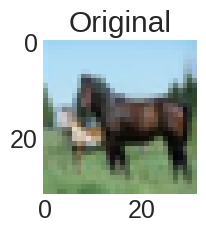

Output shape is (1, 32, 32, 3) and it should be (1, 32, 32, 3)


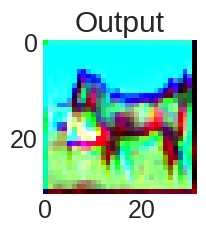

In [21]:
def plot_img(img, title='', figsize=(2, 2)):
    plt.figure(figsize=figsize)
    plt.title(title)
    plt.imshow(img)
    plt.grid(False)
    plt.show()

img_orig = tf.io.decode_png(tf.io.read_file('images/cifar10_horse.png'))
img_orig = tf.cast(img_orig, dtype=tf.float32) / 255.
img_orig = img_orig[:, :, :3]
plot_img(img_orig, title='Original', figsize=(2, 2))

tf.random.set_seed(4)
convt = Conv2DTranspose('convoluted', kernel_size=(3, 3), strides=1, activation='linear', wt_scale=0.75)
img_out = convt(tf.expand_dims(img_orig, axis=0), units_prev=3)
print(f'Output shape is {img_out.shape} and it should be (1, 32, 32, 3)')
img_out_np = np.clip(img_out[0].numpy(), 0, 1)
plot_img(img_out_np, title='Output', figsize=(2, 2))


#### `Conv2DTranspose` Image Test 2/2

This test should show you a 2x upscaled version of a CIFAR-10 image of a horse with a pervasive harsh colored checkboard pattern. Despite coloration differences and the checkboard, you should still clearly see the original horse scene.

*Make sure you have `cifar10_horse.png` downloaded from the project website and placed in a `images` project subfolder.*

Output shape is (1, 64, 64, 3) and it should be (1, 64, 64, 3)


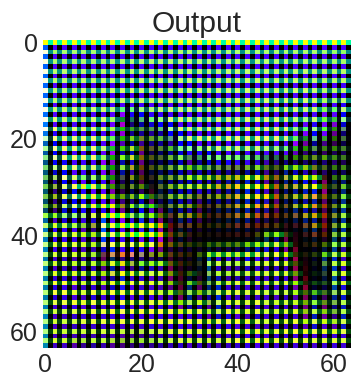

In [22]:
tf.random.set_seed(4)
convt = Conv2DTranspose('convoluted', kernel_size=(3, 3), strides=2, activation='linear', wt_scale=0.75)
img_out = convt(tf.expand_dims(img_orig, axis=0), units_prev=3)
print(f'Output shape is {img_out.shape} and it should be (1, 64, 64, 3)')
img_out_np = np.clip(img_out[0].numpy(), 0, 1)
plot_img(img_out_np, title='Output', figsize=(4, 4))


### 5d. Questions

**Question 8:** (Test 1/2) Why are the colors off in the output of the first test?

**Question 9:** (Test 1/2) Why is there a black L shape on the botton and right sides of the output?

**Question 10:** (Test 2/2) Why do we see a harsh "checkerboard" pattern in the upscaled image?

**Question 11:** (Test 2/2) Should we expect this level of harshness to persist even after training the CNN? Why or why not?

**Answer 8:** Because the transpose-convolution filters are untrained and randomly mix RGB channels.

**Answer 9:** Because we are doing valid padding, not same padding.

**Answer 10:** Because we applied a stride of 2. Uneven overlap of filter applications in transposed convolution during upsampling.

**Answer 11:** No. After CNN learns better weights, the image will look better. But checkerboard artifact will remain if we still applied strides != 1 since it is partly caused by the transposed-convolution method itself.

## Task 6: Add support for He/Kaiming Initialization

Add support for a new `'he'` weight initialization method (He/Kaiming initialization) in layers that contain weights. Start by implementing the `get_kaiming_gain` method in `Layer` to return the appropriate Kaiming gain value, depending on the activation function being used by the layer.

Then in the following classes in `conv_pcn_layers.py` update the `init_params` methods:
- `Conv2D`
- `Conv2DTranspose`

and in the following in `layers.py`:
- `Dense`

He/Kaiming initialization is helpful for accelerated learning in neural networks and improved training stability in deeper neural networks. This is important because the convolutional CNN will be the deepest network that we have built so far.

Since we will be analyzing and comparing this new weight initialization technique with our existing `'normal'` method (with the explicit `wt_scale`), make sure that your layers maintain support for both options. The instance variable `self.wt_init` should store a string that indicates which initialization technique should be used.

In [23]:
from layers import Dense
from conv_layers import Conv2D, Conv2DTranspose

#### Test `Dense`

Also re-run tests in Task 5 to make sure adding support for He/Kaiming initialization does not affect `'normal'` initialization.

In [24]:
tf.random.set_seed(0)
d = Dense('Test', units=3, wt_init='he')
d(tf.ones([2, 4]))
print(f'Your wts are\n{d.get_wts().numpy()} and should be')
print('''[[ 1.068  0.299 -0.297]
 [-0.733 -0.875  0.333]
 [-0.01   0.841  0.426]
 [ 0.424 -0.499 -0.306]]''')
print(f'Your biases are\n{d.get_b().numpy()} and should be')
print('[0. 0. 0.]')

Your wts are
[[ 1.068  0.299 -0.297]
 [-0.733 -0.875  0.333]
 [-0.01   0.841  0.426]
 [ 0.424 -0.499 -0.306]] and should be
[[ 1.068  0.299 -0.297]
 [-0.733 -0.875  0.333]
 [-0.01   0.841  0.426]
 [ 0.424 -0.499 -0.306]]
Your biases are
[0. 0. 0.] and should be
[0. 0. 0.]


#### Test `Conv2D`

In [25]:
tf.random.set_seed(0)
c = Conv2D('Test', units=3, wt_init='he', kernel_size=(2,2))
c(tf.ones([1, 6, 6, 2]))
print(f'Your wts are\n{c.get_wts().numpy()} and should be')
print('''[[[[ 0.756  0.211 -0.21 ]
   [-0.518 -0.618  0.235]]

  [[-0.007  0.594  0.301]
   [ 0.3   -0.353 -0.216]]]


 [[[ 0.397 -0.349 -0.48 ]
   [-0.45  -0.18  -0.112]]

  [[ 0.152  0.261  0.078]
   [ 0.794 -0.398  0.039]]]]''')
print(f'Your biases are\n{c.get_b().numpy()} and should be')
print('[0. 0. 0.]')

Your wts are
[[[[ 0.756  0.211 -0.21 ]
   [-0.518 -0.618  0.235]]

  [[-0.007  0.594  0.301]
   [ 0.3   -0.353 -0.216]]]


 [[[ 0.397 -0.349 -0.48 ]
   [-0.45  -0.18  -0.112]]

  [[ 0.152  0.261  0.078]
   [ 0.794 -0.398  0.039]]]] and should be
[[[[ 0.756  0.211 -0.21 ]
   [-0.518 -0.618  0.235]]

  [[-0.007  0.594  0.301]
   [ 0.3   -0.353 -0.216]]]


 [[[ 0.397 -0.349 -0.48 ]
   [-0.45  -0.18  -0.112]]

  [[ 0.152  0.261  0.078]
   [ 0.794 -0.398  0.039]]]]
Your biases are
[0. 0. 0.] and should be
[0. 0. 0.]


#### Test `Conv2DTranspose`

In [26]:
tf.random.set_seed(0)
c = Conv2DTranspose('Test', wt_init='he', kernel_size=(2, 2))
c(tf.ones([1, 5, 5, 4]), units_prev=2)
print(f'Your wts shape is {c.get_wts().shape} and should be (2, 2, 2, 4).')
print(f'Your wts are\n{c.get_wts().numpy()} and should be')
print('''[[[[ 0.378  0.106 -0.105 -0.259]
   [-0.309  0.118 -0.003  0.297]]

  [[ 0.151  0.15  -0.176 -0.108]
   [ 0.198 -0.174 -0.24  -0.225]]]


 [[[-0.09  -0.056  0.076  0.13 ]
   [ 0.039  0.397 -0.199  0.019]]

  [[-0.045 -0.215  0.055  0.179]
   [-0.611  0.007  0.433 -0.178]]]]''')
print(f'Your biases are\n{c.get_b().numpy()} and should be')
print('[0. 0.]')

Your wts shape is (2, 2, 2, 4) and should be (2, 2, 2, 4).
Your wts are
[[[[ 0.378  0.106 -0.105 -0.259]
   [-0.309  0.118 -0.003  0.297]]

  [[ 0.151  0.15  -0.176 -0.108]
   [ 0.198 -0.174 -0.24  -0.225]]]


 [[[-0.09  -0.056  0.076  0.13 ]
   [ 0.039  0.397 -0.199  0.019]]

  [[-0.045 -0.215  0.055  0.179]
   [-0.611  0.007  0.433 -0.178]]]] and should be
[[[[ 0.378  0.106 -0.105 -0.259]
   [-0.309  0.118 -0.003  0.297]]

  [[ 0.151  0.15  -0.176 -0.108]
   [ 0.198 -0.174 -0.24  -0.225]]]


 [[[-0.09  -0.056  0.076  0.13 ]
   [ 0.039  0.397 -0.199  0.019]]

  [[-0.045 -0.215  0.055  0.179]
   [-0.611  0.007  0.433 -0.178]]]]
Your biases are
[0. 0.] and should be
[0. 0.]


## Task 7: Group normalization

Inspired by evidence that the small groups of neurons in the brain normalize signals to keep activations within reasonable levels, let's add support for **group normalization**, a machine learning mechanism that achieves an analogous effect, to our CNN. Recall that this involves standardizing (i.e. a type of normalization) `net_in` values within small **groups** of adjacent neurons within a network layer.

Implementing group normalization requires changes to the following parts of the codebase:

**Layer:**
- Constructor: If you have not already done so, make instance variables for the group normalization parameter (`do_group_norm`).
- `set_num_groups`: Allows the user to configure the number of normalization groups group norm should use.
- `is_doing_groupnorm`: Return whether the layer is configured to perform group normalization.
- `init_groupnorm_params`: Initialize the group norm gain and bias parameters, turn off the ordinary bias.
- `__call__`: Update how you compute the forward pass through the layer. If we are doing group norm AND the group norm gain is not `None`, perform group normalization on the net input before the layer's activation is computed.

**DeepNetwork:**
- `init_groupnorm_params`: Calls each layer's method `init_groupnorm_params`. This gets called in the `compile` method.

**Dense**:
- `compute_group_norm(net_in, eps=0.001)`: Performs group normalization on the net input signal.

**Conv2D**:
- `compute_group_norm(net_in, eps=0.001)`: Performs group normalization on the net input signal.


**Conv2DTranspose**:
- `__call__`: Update how you compute the forward pass through the layer. If we are doing group norm AND the group norm gain is not `None`, perform group normalization on the net input before the layer's activation is computed. *This should be the same as what you did in `Layer`. Be careful if copy-pasting because the function call parameters are different!*
- You do not need to write `compute_group_norm` here because the class inherits it from `Conv2D` :)


#### Test: `Dense` group norm (1/2)

In [27]:
from layers import Dense

In [28]:
print(30*'-', 'Test: Dense w/ linear', 30*'-')

tf.random.set_seed(0)
dense = Dense('Test', units=16, prev_layer_or_block=None, wt_init='he', activation='linear', do_group_norm=True)
dense(tf.ones([1, 3]))
dense.init_groupnorm_params()

tf.random.set_seed(1)
net_acts = dense(tf.random.uniform([2, 3]))
print(f'Your net_acts with 8 groups are\n{net_acts}')
print('They should be:')
print('''[[ 0.212  0.392 -1.484  0.141 -0.524  2.087 -0.95   0.127 -0.051 -0.965
   0.878  0.289 -1.204  0.893  1.48  -1.32 ]
 [ 1.027  0.779 -1.806 -0.471 -0.955  1.237 -0.332  0.521  0.31  -0.501
   0.821 -0.665  1.043  1.079 -0.03  -2.057]]''')

print(30*'-', 'Test: Dense w/ ReLU', 30*'-')

tf.random.set_seed(0)
dense = Dense('Test', units=12, prev_layer_or_block=None, wt_init='he', do_group_norm=True)
dense(tf.ones([1, 3]))
dense.init_groupnorm_params()
dense.set_num_groups(6)

tf.random.set_seed(1)
net_acts = dense(tf.random.uniform([2, 3]))
print(f'Your net_acts with 6 groups are\n{net_acts}')
print('They should be:')
print('''[[0.999 0.    0.    0.991 0.    0.999 0.998 0.    0.    0.998 0.    0.999]
 [0.998 0.    0.    0.965 0.    0.999 0.998 0.    0.    0.996 0.    0.999]]
''')

------------------------------ Test: Dense w/ linear ------------------------------
Your net_acts with 8 groups are
[[ 0.212  0.392 -1.484  0.141 -0.524  2.087 -0.95   0.127 -0.051 -0.965
   0.878  0.289 -1.204  0.893  1.48  -1.32 ]
 [ 1.027  0.779 -1.806 -0.471 -0.955  1.237 -0.332  0.521  0.31  -0.501
   0.821 -0.665  1.043  1.079 -0.03  -2.057]]
They should be:
[[ 0.212  0.392 -1.484  0.141 -0.524  2.087 -0.95   0.127 -0.051 -0.965
   0.878  0.289 -1.204  0.893  1.48  -1.32 ]
 [ 1.027  0.779 -1.806 -0.471 -0.955  1.237 -0.332  0.521  0.31  -0.501
   0.821 -0.665  1.043  1.079 -0.03  -2.057]]
------------------------------ Test: Dense w/ ReLU ------------------------------
Your net_acts with 6 groups are
[[0.999 0.    0.    0.991 0.    0.999 0.998 0.    0.    0.998 0.    0.999]
 [0.998 0.    0.    0.965 0.    0.999 0.998 0.    0.    0.996 0.    0.999]]
They should be:
[[0.999 0.    0.    0.991 0.    0.999 0.998 0.    0.    0.998 0.    0.999]
 [0.998 0.    0.    0.965 0.    0.999 0.99

#### Test: `Dense` group norm (2/2)

In [29]:
print(30*'-', 'Test: Dense w/ linear', 30*'-')

tf.random.set_seed(0)
dense = Dense('Test', units=16, prev_layer_or_block=None, wt_init='he', activation='linear', do_group_norm=True)
dense(tf.ones([1, 3]))
dense.init_groupnorm_params()
dense.set_num_groups(4)
dense.gn_gain = tf.range(16, dtype=tf.float32)
dense.gn_bias = tf.range(16, dtype=tf.float32)[::-1]

tf.random.set_seed(1)
net_acts = dense(tf.random.uniform([2, 3]))
print(f'Your net_acts with 4 groups are\n{net_acts}')
print('They should be:')
print('''[[ 15.     14.762   9.57   13.288   8.567  18.162   3.155   7.649   5.94
   -7.481  17.551   8.13   -8.248  11.724  18.078 -15.457]
 [ 15.     14.794  10.012  11.063   5.853  16.709   5.766  11.388  11.192
   -1.285  18.648  -7.872  12.721  12.903   0.574 -24.275]]''')


------------------------------ Test: Dense w/ linear ------------------------------
Your net_acts with 4 groups are
[[ 15.     14.762   9.57   13.288   8.567  18.162   3.155   7.649   5.94
   -7.481  17.551   8.13   -8.248  11.724  18.078 -15.457]
 [ 15.     14.794  10.012  11.063   5.853  16.709   5.766  11.388  11.192
   -1.285  18.648  -7.872  12.721  12.903   0.574 -24.275]]
They should be:
[[ 15.     14.762   9.57   13.288   8.567  18.162   3.155   7.649   5.94
   -7.481  17.551   8.13   -8.248  11.724  18.078 -15.457]
 [ 15.     14.794  10.012  11.063   5.853  16.709   5.766  11.388  11.192
   -1.285  18.648  -7.872  12.721  12.903   0.574 -24.275]]


#### Test: `Conv2D` group norm (1/2)

In [30]:
from conv_layers import Conv2D

In [31]:
print(30*'-', 'Test: Conv2D w/ linear', 30*'-')

tf.random.set_seed(0)
conv = Conv2D('Test', units=8, wt_init='he', activation='linear', do_group_norm=True)
conv(tf.ones([1, 2, 2, 3]))
conv.init_groupnorm_params()

tf.random.set_seed(1)
net_acts = conv(tf.random.uniform([2, 2, 2, 3]))
print(f'1st sample net_acts are\n{net_acts[0]}')
print('They should be:')
print('''[[[ 0.718  0.586 -0.759 -0.374  0.778  0.562 -1.931 -0.831]
  [ 0.766  0.238 -0.32  -0.387 -0.338  1.342 -1.148  0.36 ]]

 [[ 1.995  0.664 -0.762 -1.227 -1.095  1.592 -1.366  1.066]
  [ 1.417  0.629 -0.763 -0.853 -0.258  1.062 -1.574  0.209]]]''')


------------------------------ Test: Conv2D w/ linear ------------------------------
1st sample net_acts are
[[[ 0.718  0.586 -0.759 -0.374  0.778  0.562 -1.931 -0.831]
  [ 0.766  0.238 -0.32  -0.387 -0.338  1.342 -1.148  0.36 ]]

 [[ 1.995  0.664 -0.762 -1.227 -1.095  1.592 -1.366  1.066]
  [ 1.417  0.629 -0.763 -0.853 -0.258  1.062 -1.574  0.209]]]
They should be:
[[[ 0.718  0.586 -0.759 -0.374  0.778  0.562 -1.931 -0.831]
  [ 0.766  0.238 -0.32  -0.387 -0.338  1.342 -1.148  0.36 ]]

 [[ 1.995  0.664 -0.762 -1.227 -1.095  1.592 -1.366  1.066]
  [ 1.417  0.629 -0.763 -0.853 -0.258  1.062 -1.574  0.209]]]


In [32]:
print(f'2nd sample of net_acts are\n{net_acts[1]}')
print('They should be:')
print('''[[[ 2.176  0.885 -0.968 -1.344 -0.773  1.162 -1.521  0.741]
  [ 0.281  0.289 -0.379 -0.15   0.488  0.126 -0.925 -0.525]]

 [[ 2.261  1.025 -1.118 -1.31  -0.414  1.483 -2.171  0.428]
  [ 0.005 -0.028  0.     0.072  0.018  0.648 -0.479  0.018]]]''')

2nd sample of net_acts are
[[[ 2.176  0.885 -0.968 -1.344 -0.773  1.162 -1.521  0.741]
  [ 0.281  0.289 -0.379 -0.15   0.488  0.126 -0.925 -0.525]]

 [[ 2.261  1.025 -1.118 -1.31  -0.414  1.483 -2.171  0.428]
  [ 0.005 -0.028  0.     0.072  0.018  0.648 -0.479  0.018]]]
They should be:
[[[ 2.176  0.885 -0.968 -1.344 -0.773  1.162 -1.521  0.741]
  [ 0.281  0.289 -0.379 -0.15   0.488  0.126 -0.925 -0.525]]

 [[ 2.261  1.025 -1.118 -1.31  -0.414  1.483 -2.171  0.428]
  [ 0.005 -0.028  0.     0.072  0.018  0.648 -0.479  0.018]]]


In [33]:
print(30*'-', 'Test: Conv2D w/ ReLU', 30*'-')

tf.random.set_seed(0)
conv = Conv2D('Test', units=12, kernel_size=(2, 2), prev_layer_or_block=None, wt_init='he', do_group_norm=True)
conv(tf.ones([1, 2, 2, 3]))
conv.init_groupnorm_params()
conv.set_num_groups(6)

tf.random.set_seed(1)
net_acts = conv(tf.random.uniform([1, 2, 2, 3]))
print(f'Your net_acts are\n{net_acts[0]}')
print('They should be:')
print('''[[[1.631 0.    1.542 0.    0.    0.767 0.304 0.    0.    0.    0.
   0.79 ]
  [0.771 0.    1.535 0.272 0.    1.521 0.    0.548 0.42  0.    0.
   0.978]]

 [[0.264 0.073 0.    0.    0.    0.245 1.673 0.    1.018 0.011 0.
   0.685]
  [0.642 0.    0.    0.    0.    0.815 0.633 0.    0.6   1.387 0.
   1.067]]]''')

------------------------------ Test: Conv2D w/ ReLU ------------------------------
Your net_acts are
[[[1.631 0.    1.542 0.    0.    0.767 0.304 0.    0.    0.    0.
   0.79 ]
  [0.771 0.    1.535 0.272 0.    1.521 0.    0.548 0.42  0.    0.
   0.978]]

 [[0.264 0.073 0.    0.    0.    0.245 1.673 0.    1.018 0.011 0.
   0.685]
  [0.642 0.    0.    0.    0.    0.815 0.633 0.    0.6   1.387 0.
   1.067]]]
They should be:
[[[1.631 0.    1.542 0.    0.    0.767 0.304 0.    0.    0.    0.
   0.79 ]
  [0.771 0.    1.535 0.272 0.    1.521 0.    0.548 0.42  0.    0.
   0.978]]

 [[0.264 0.073 0.    0.    0.    0.245 1.673 0.    1.018 0.011 0.
   0.685]
  [0.642 0.    0.    0.    0.    0.815 0.633 0.    0.6   1.387 0.
   1.067]]]


#### Test: `Conv2D` group norm (2/2)

In [34]:
print(30*'-', 'Test: Conv2D w/ ReLU', 30*'-')

tf.random.set_seed(0)
conv = Conv2D('Test', units=12, kernel_size=(2, 2), prev_layer_or_block=None, wt_init='he', do_group_norm=True)
conv(tf.ones([1, 2, 2, 3]))
conv.init_groupnorm_params()
conv.set_num_groups(6)
conv.gn_gain = tf.range(12, dtype=tf.float32)
conv.gn_bias = tf.range(12, dtype=tf.float32)[::-1]

tf.random.set_seed(1)
net_acts = conv(tf.random.uniform([1, 2, 2, 3]))
print(f'Your net_acts are\n{net_acts[0]}')
print('They should be:')
print('''[[[11.     8.347 12.084  3.924  5.659  9.834  6.825  0.     0.     0.
    0.     8.693]
  [11.     9.186 12.07   8.816  5.666 13.603  4.631  7.837  6.358  0.
    0.    10.76 ]]

 [[11.    10.073  8.966  5.676  0.     7.223 15.039  0.    11.143  2.102
    0.     7.53 ]
  [11.     9.087  7.825  6.169  3.728 10.073  8.796  2.185  7.804 14.479
    0.344 11.739]]]''')


------------------------------ Test: Conv2D w/ ReLU ------------------------------
Your net_acts are
[[[11.     8.347 12.084  3.924  5.659  9.834  6.825  0.     0.     0.
    0.     8.693]
  [11.     9.186 12.07   8.816  5.666 13.603  4.631  7.837  6.358  0.
    0.    10.76 ]]

 [[11.    10.073  8.966  5.676  0.     7.223 15.039  0.    11.143  2.102
    0.     7.53 ]
  [11.     9.087  7.825  6.169  3.728 10.073  8.796  2.185  7.804 14.479
    0.344 11.739]]]
They should be:
[[[11.     8.347 12.084  3.924  5.659  9.834  6.825  0.     0.     0.
    0.     8.693]
  [11.     9.186 12.07   8.816  5.666 13.603  4.631  7.837  6.358  0.
    0.    10.76 ]]

 [[11.    10.073  8.966  5.676  0.     7.223 15.039  0.    11.143  2.102
    0.     7.53 ]
  [11.     9.087  7.825  6.169  3.728 10.073  8.796  2.185  7.804 14.479
    0.344 11.739]]]


#### Test: `Conv2DTranspose` group norm

In [35]:
print(30*'-', 'Test: Conv2DTranspose w/ ReLU', 30*'-')

tf.random.set_seed(0)
convt = Conv2DTranspose('Test', kernel_size=(2, 2), wt_init='he', activation='relu', do_group_norm=True)
convt(tf.ones([1, 2, 2, 12]), units_prev=6)
convt.init_groupnorm_params()
convt.set_num_groups(3)
convt.gn_gain = tf.range(6, dtype=tf.float32)
convt.gn_bias = tf.range(6, dtype=tf.float32)[::-1]

tf.random.set_seed(1)
net_acts = convt(tf.random.uniform([1, 2, 2, 12]), units_prev=6)
print(f'Your net_acts are\n{net_acts[0]}')
print('They should be:')
print('''[[[5.    3.676 5.52  1.397 4.233 0.   ]
  [5.    3.646 3.482 0.    0.589 0.   ]]

 [[5.    3.954 4.491 0.    7.371 0.   ]
  [5.    1.924 5.704 0.    4.157 0.816]]]''')


------------------------------ Test: Conv2DTranspose w/ ReLU ------------------------------
Your net_acts are
[[[5.    3.676 5.52  1.397 4.233 0.   ]
  [5.    3.646 3.482 0.    0.589 0.   ]]

 [[5.    3.954 4.491 0.    7.371 0.   ]
  [5.    1.924 5.704 0.    4.157 0.816]]]
They should be:
[[[5.    3.676 5.52  1.397 4.233 0.   ]
  [5.    3.646 3.482 0.    0.589 0.   ]]

 [[5.    3.954 4.491 0.    7.371 0.   ]
  [5.    1.924 5.704 0.    4.157 0.816]]]


## Task 8: The Convolutional PCN Block

Our conv PCNs will have the following rough architecture (recall the `Conv2D` and `Conv2DTranspose` 'sit' at the same level/depth of the network):

Input → ... → [Conv2D, Conv2DTranspose, Dropout] → ... → [Conv2D, Conv2DTranspose, Dropout] → ... → Output

Given that the trio of `Conv2D`, `Conv2DTranspose`, and `Dropout` layers replicate over and over again, it would be tedious and error prone to implement the network by copy-pasting these layers over and over again. Instead, we will use a **block** design that is common in deep learning, where we create a "meta layer" (block) composed of a pair of `Conv2D`, `Conv2DTranspose`, and `Dropout` layers (`ConvPCNBlock`). So instead of manually creating 3 new layers, we add a single block object each time. Blocks offer a quicker and more efficient way to build the convolutional PCNs.


### 8a. Download `block.py` from the project website

Place it in your working project folder. This file allows `Block` objects to work alongside `Layer` objects when building nets with our neural network library. The file `block.py` should not require any modification.

In [36]:
from conv_pcn_blocks import ConvPCNBlock

ModuleNotFoundError: No module named 'conv_pcn_blocks'

### 8b. Implement the Convolutional PCN Block (`ConvPCNBlock`) in `conv_pcn_blocks.py`

This is the main building block of the convolutional PCN, consisting of the following layers:
- `Conv2D` (*for feedforward signals*)
- `Conv2DTranspose` (*for feedback signals*)
- `Dropout` (*optional*)

These layers are used within the `ConvPCNBlock` to compute and minimize the top-down prediction error within the block (*i.e. get the top-down signal to predict the data as closely as possible*). The main difference between the dense PCN and convolutional PCN is instead of doing `num_steps` iterative prediction sweeps *across the entire net*, we do `num_steps` steps *locally* between successive layers *within each current block only*.

#### Prediction error equation

Recall that the prediction error is computed as:

$$
\text{ReLU}(x_{\text{orig}} - x_{\text{pred}})
$$

where $x_{\text{orig}}$ is the current mini-batch input to the block and $x_{\text{pred}}$ is the feedback-based input reconstruction.


#### State update equation

Recall that the state in the `ConvPCNBlock` ($\text{Mem}_{i, j} (0)$) is initialized to the feedforward netAct from the 2D conv layer (*analogous to what we did for the dense PCN*) and updated as:

$$
\text{Mem}_{i, j} (t) = \text{Mem}_{i, j} (t-1) + \eta_{\text{state}} \varepsilon_{i,j}
$$

where $\text{Mem}_{i, j} (t)$ is the medium term memory state of neuron $j$ in the block for sample $i$ at time step $t$, $\eta_{\text{state}}$ is the state learning rate, and $\varepsilon_{i,j}$ is the prediction error "forwarded" through the current 2D convolutional layer.

*See class notes for more detail.*

#### Test `ConvPCNBlock`

In [ ]:
print('===============Test 1: 0 steps, no dropout, no group norm===============')
tf.random.set_seed(0)
test_block = ConvPCNBlock('TestBlock', units=5, kernel_size=(2, 2), strides=1, num_steps=0, state_lr=0.5,
                          dropout_rate=None, wt_init='he', do_group_norm=False, prev_layer_or_block=None)
tf.random.set_seed(1)
test_x = tf.random.normal(shape=(1, 2, 2, 3))
test_state = test_block(test_x)
print('Your state is:')
print(test_state)
print('and it should be:')
print('''tf.Tensor(
[[[[0.    0.    0.    0.    1.195]
   [0.    1.407 0.575 0.392 0.062]]

  [[0.041 0.148 0.    0.046 0.   ]
   [0.167 1.024 0.382 0.231 0.   ]]]], shape=(1, 2, 2, 5), dtype=float32)''')

In [ ]:
print('===============Test 2: 1 step, no dropout, no group norm===============')
tf.random.set_seed(0)
test_block = ConvPCNBlock('TestBlock', units=5, kernel_size=(2, 2), strides=1, num_steps=1, state_lr=0.5,
                          dropout_rate=None, wt_init='he', do_group_norm=False, prev_layer_or_block=None)
tf.random.set_seed(1)
test_x = tf.random.normal(shape=(1, 2, 2, 3))
test_state = test_block(test_x)
print('Your state is:')
print(test_state)
print('and it should be:')
print('''tf.Tensor(
[[[[0.    0.    0.    0.    1.22 ]
   [0.    1.407 0.575 0.392 0.062]]

  [[0.048 0.148 0.    0.069 0.013]
   [0.167 1.024 0.382 0.231 0.   ]]]], shape=(1, 2, 2, 5), dtype=float32)''')

In [ ]:
print('===============Test 3: 5 steps, no dropout, no group norm===============')
tf.random.set_seed(0)
test_block = ConvPCNBlock('TestBlock', units=5, kernel_size=(2, 2), strides=1, num_steps=5, state_lr=0.5,
                          dropout_rate=None, wt_init='he', do_group_norm=False, prev_layer_or_block=None)
tf.random.set_seed(1)
test_x = tf.random.normal(shape=(1, 2, 2, 3))
test_state = test_block(test_x)
print('Your state is:')
print(test_state)
print('and it should be:')
print('''tf.Tensor(
[[[[0.    0.    0.    0.    1.308]
   [0.    1.407 0.575 0.392 0.062]]

  [[0.077 0.148 0.    0.165 0.064]
   [0.167 1.024 0.382 0.231 0.   ]]]], shape=(1, 2, 2, 5), dtype=float32)''')

In [ ]:
print('===============Test 4: 5 steps, dropout, no group norm===============')
tf.random.set_seed(0)
test_block = ConvPCNBlock('TestBlock', units=5, kernel_size=(2, 2), strides=1, num_steps=5, state_lr=0.5,
                          dropout_rate=0.75, wt_init='he', do_group_norm=False, prev_layer_or_block=None)
test_block.layers[-1].set_mode(True)
tf.random.set_seed(1)
test_x = tf.random.normal(shape=(1, 2, 2, 3))
test_state = test_block(test_x)
print('Your state is:')
print(test_state)
print('and it should be:')
print('''tf.Tensor(
[[[[0.    0.    0.    0.    0.   ]
   [0.    0.    0.    1.569 0.   ]]

  [[0.    0.    0.    0.    0.   ]
   [0.67  0.    1.526 0.    0.   ]]]], shape=(1, 2, 2, 5), dtype=float32)''')
print('or')
print('''tf.Tensor(
[[[[0.    0.    0.    0.    0.   ]
   [0.    0.    0.    0.    0.247]]

  [[0.    0.    0.    0.    0.   ]
   [0.    0.    0.    0.925 0.   ]]]], shape=(1, 2, 2, 5), dtype=float32)''')

In [ ]:
print('===============Test 5: 5 steps, no dropout, group norm===============')
tf.random.set_seed(0)
test_block = ConvPCNBlock('TestBlock', units=8, kernel_size=(2, 2), strides=1, num_steps=5, state_lr=0.5,
                          dropout_rate=None, wt_init='he', do_group_norm=True, prev_layer_or_block=None)
test_block.layers[-1].set_mode(True)
test_block.layers[0].set_num_groups(2)
test_block.layers[1].set_num_groups(2)
tf.random.set_seed(1)
test_x = tf.random.normal(shape=(1, 2, 2, 4))
test_state = test_block(test_x)
print('Your state is:')
print(test_state)
print('and it should be:')
print('''tf.Tensor(
[[[[0.    0.771 0.    0.    0.484 0.962 1.838 3.593]
   [0.075 0.    0.    0.    0.    0.493 0.    0.   ]]

  [[2.261 2.245 1.21  0.396 0.13  0.    0.    0.   ]
   [1.201 0.108 0.573 0.721 0.    0.423 0.    0.004]]]], shape=(1, 2, 2, 8), dtype=float32)''')